<center>
  <font size="10" color="brown"><b>Bank Transaction Fraud Detection</b></font><br>
</center>

## Import Libraries

In [2]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing and modeling libraries
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

## Load Dataset

In [3]:
# Load the datasets
df = pd.read_csv("../dataset/bank_transactions_data.csv")

# Verify shapes
print("Data Shape:", df.shape)

Data Shape: (2512, 16)


## Data Preview & Info

In [4]:
# Display few rows of each dataset
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [5]:
# Display information about the DataFrames
print("Data Info: ")
df.info()

Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalan

<div style="text-align: left;">
    <font size="5" color="white"><b>Insights from Initial Data Exploration</b></font>
</div>

**Dataset Size and Strcuture**  


- The dataset contains 2512 samples with 16 features.  

- Features include a mix of transactional details, customer demographics, and behavioral indicators.  

**Feature Categories**  

**(1) Identifiers**
- TransactionID
- AccountID
- DeviceID
- MerchantID

**(2) Transaction Details**
- TransactionAmount
- TransactionDate
- TransactionType
- TransactionDuration
- Channel

**(3) Customer Information**
- CustomerAge
- CustomerOccupation
- AccountBalance

**(4) Security and Behavioral Features**
- LoginAttempts
- IP Address
- Location
- PreviousTransactionDate

**Data types**
- Numerical attributes stored as int64 or float64.
- Transactional, temporal, and identifier attributes stored as object.


In [25]:
# Display numerical features
num_features = ["TransactionAmount", "CustomerAge", "TransactionDuration", "AccountBalance", "LoginAttempts"]

print("Data describe numerical features:")
num_summary = df[num_features].describe().T
num_summary

Data describe numerical features:


,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.0,297.593778,291.946243,0.26,81.885,211.14,414.5275,1919.11
CustomerAge,2512.0,44.673965,17.792198,18.00,27.000,45.00,59.0000,80.00
TransactionDuration,2512.0,119.643312,69.963757,10.00,63.000,112.50,161.0000,300.00
AccountBalance,2512.0,5114.302966,3900.942499,101.25,1504.370,4735.51,7678.8200,14977.99
LoginAttempts,2512.0,1.124602,0.602662,1.00,1.000,1.00,1.0000,5.00


**Numerical Feature Insights**  
- **TransactionAmount:** Ranges from 0.26 to 1,919.11, with a mean of 297.59 but a median of only 211.14 — the gap between mean and median confirms the right-skew, a small number of large transactions pull the average up.  

- **CustomerAge:** Ranges from 18 to 80, with a mean of 44.7 and median of 45 — a fairly even, balanced spread across age groups, no strong skew.  

- **TransactionDuration:** Ranges from 10 to 300 seconds, with a mean of 119.6 and median of 112.5 — most transactions complete quickly, with a modest right-skew from longer-duration cases.  

- **AccountBalance:** Ranges from 101.25 to 14,977.99, with a mean of 5,114.30 and median of 4,735.51 — wide spread across customers, from low-balance to high-balance accounts, with a mild right-skew from higher-balance outliers.  

- **LoginAttempts:** Only 5 distinct values appear (1 through 5), and the value 1 accounts for 95.1% of all transactions (2,390 of 2,512) — heavily concentrated at the low end, so any transaction with 3+ attempts is a meaningful deviation worth flagging.

In [7]:
# Display categorical features
cat_features = ["TransactionType", "Channel", "CustomerOccupation", "Location"]

print("Data describe categorical features:")
cat_summary = df[cat_features].describe().T
cat_summary

Data describe categorical features:


,count,unique,top,freq
TransactionType,2512,2,Debit,1944
Channel,2512,3,Branch,868
CustomerOccupation,2512,4,Student,657
Location,2512,43,Fort Worth,70


**Categorical Feature Insights**  
- **TransactionType:** Highly imbalanced — Debit transactions dominate (77.4%, 1,944 of 2,512), driving most activity.  

- **Channel:** Three channels used; Branch is most common (34.6%, 868 transactions), followed by Online and ATM at fairly similar shares.  

- **CustomerOccupation:** Students form the largest group (26.2%, 657 transactions), indicating a young, active customer base among the 4 occupation categories.

- **Location:** 43 cities — geographically diverse, with Fort Worth most frequent (70 transactions, 2.8%).

## Data Quality Checks

In [8]:
# Check for missing values in the datasets
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"Missing Value Summary for: {dataset_name}")
    else:
        print("Missing Value Summary:")
    print("=" * 40)

    if total_missing == 0:
        print(f"No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))

        print(f"\nTotal missing values: {total_missing:,} out of {total_rows:,} rows.")

displayNULL(df, dataset_name="Dataset")

Missing Value Summary for: Dataset
No missing values detected in 2,512 rows.


In [9]:
# Check for duplicate records in the datasets
def displayDuplicates(df, dataset_name=None):
    total_rows = len(df)

    dup_count = df.duplicated().sum()
    dup_pct = round((dup_count / total_rows * 100), 2)

    print("=" * 40)
    if dataset_name:
        print(f"Duplicate Record Summary for: {dataset_name}")
    else:
        print("Duplicate Record Summary:")
    print("=" * 40)

    if dup_count == 0:
        print(f"No duplicate records detected in {total_rows:,} rows.")
    else:
        summary_df = pd.DataFrame({
            "Metric": ["Duplicate Rows", "Duplicate_%"],
            "Value": [f"{dup_count:,}", f"{dup_pct}%"]
        })

        try:
            from tabulate import tabulate
            print(tabulate(summary_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left")))
        except ImportError:
            print(summary_df.to_string(index=False))

        print(f"\nTotal duplicate rows: {dup_count:,} out of {total_rows:,} rows.")

displayDuplicates(df, dataset_name="Dataset")

Duplicate Record Summary for: Dataset
No duplicate records detected in 2,512 rows.


In [10]:
# Parse dates
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"])

In [11]:
# Check for outliers in the datasets using IQR method
def displayOutliers(df, dataset_name=None, numeric_cols=None):
    total_rows = len(df)

    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    rows = []
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        if outlier_count > 0:
            rows.append({"Feature": col, "Outlier Count": outlier_count})

    print("=" * 40)
    if dataset_name:
        print(f"Outlier Summary for: {dataset_name}")
    else:
        print("Outlier Summary:")
    print("=" * 40)

    if not rows:
        print(f"No outliers detected in {total_rows:,} rows (IQR method).")
        return

    outlier_df = pd.DataFrame(rows).sort_values(by="Outlier Count", ascending=False).reset_index(drop=True)
    display(outlier_df)

    print(f"\nTotal outlier values: {outlier_df['Outlier Count'].sum():,} across {len(outlier_df)} feature(s), out of {total_rows:,} rows.")


displayOutliers(df, dataset_name="Dataset")

Outlier Summary for: Dataset


,Feature,Outlier Count
0,LoginAttempts,122
1,TransactionAmount,113



Total outlier values: 235 across 2 feature(s), out of 2,512 rows.


<div style="text-align: left;">
    <font size="5" color="white"><b>Data Quality Insights: Missing Values, Duplicates and Outliers</b></font>
</div>

**Missing Values Analysis**
- A thorough examination for missing values was conducted across the dataset.
- **Result:** No missing values were detected — confirming clean synthetic data suitable for model training.

**Duplicate Records Analysis**
- A check for exact duplicate rows was performed, since duplicates could artificially inflate performance or introduce bias.
- **Result:** No duplicates detected in 2,512 rows — confirming predictions will be made on unique samples.

**Outlier Analysis**
- The dataset was also examined for outliers using the IQR method.
- **Result:** Outliers were found in features such as TransactionAmount and AccountBalance. These were not removed, since they reflect realistic variation in financial behavior rather than data errors.

**Conclusion**
- Data quality across the dataset is strong — no missing values or duplicate records were found, which means the data can be used as-is without cleanup steps like imputation or de-duplication.

- Outliers do exist in features like TransactionAmount and AccountBalance, but rather than being treated as errors, they are kept in place since they likely reflect genuine variation in spending and balance behavior — and may even be useful signals for later anomaly detection.

- With these checks complete, the dataset is ready to move into modeling, needing only standard preparation steps such as encoding categorical variables and scaling numerical features, with outliers handled thoughtfully rather than removed by default.

## Exploratory Data Analysis

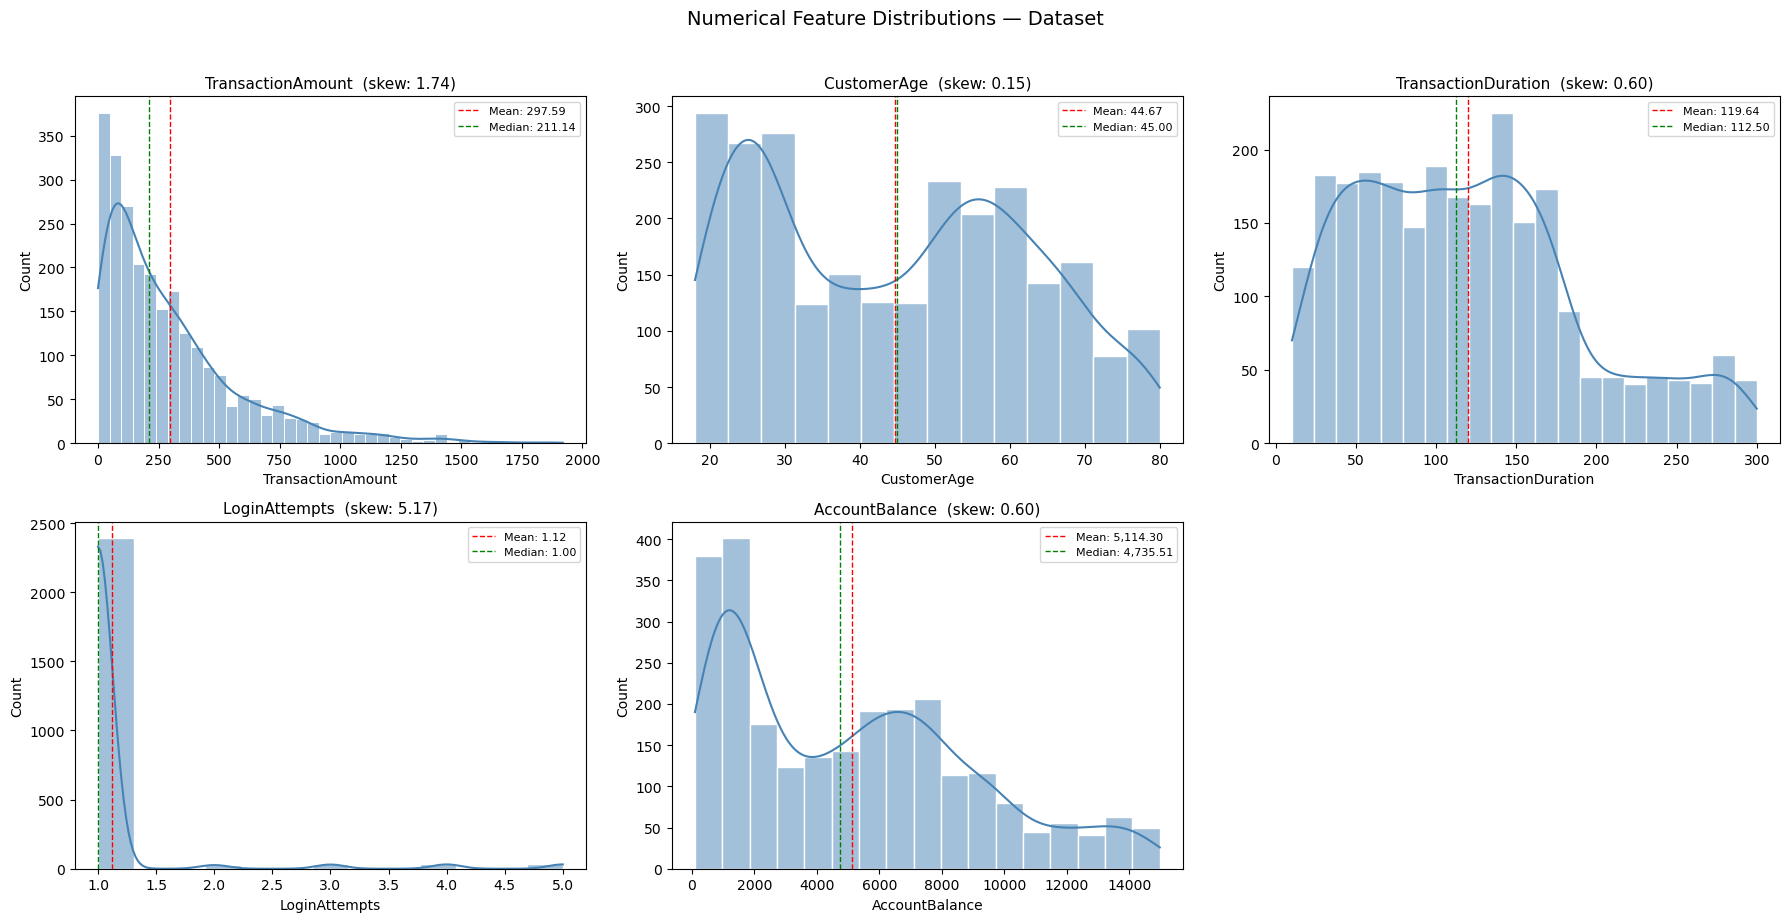

In [12]:
# Numerical distributions
def plot_numerical_distributions(df, numeric_cols=None, dataset_name=None):
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    n_cols = len(numeric_cols)
    if n_cols == 0:
        print("No numerical columns found to plot.")
        return

    ncols_grid = 3
    nrows_grid = -(-n_cols // ncols_grid)  # ceiling division, sizes the grid to fit exactly

    fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(6 * ncols_grid, 4.5 * nrows_grid))
    axes = np.array(axes).reshape(-1)  # flatten regardless of grid shape

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        data = df[col].dropna()

        sns.histplot(data, kde=True, ax=ax, color="steelblue", edgecolor="white")

        mean_val = data.mean()
        median_val = data.median()
        skew_val = data.skew()

        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1, label=f"Mean: {mean_val:,.2f}")
        ax.axvline(median_val, color="green", linestyle="--", linewidth=1, label=f"Median: {median_val:,.2f}")

        ax.set_title(f"{col}  (skew: {skew_val:.2f})", fontsize=11)
        ax.set_xlabel(col)
        ax.legend(fontsize=8)

    # Remove any unused subplot axes so nothing renders blank
    for j in range(n_cols, len(axes)):
        fig.delaxes(axes[j])

    title = f"Numerical Feature Distributions — {dataset_name}" if dataset_name else "Numerical Feature Distributions"
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_numerical_distributions(df, dataset_name="Dataset")

In [29]:
def check_skewness(data = df, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass
    
    print(f"\nSkewness for dataset:")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<10} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+10f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+10f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

skew_feature, skew_df = check_skewness()


Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
LoginAttempts                  |  +5.173491 | Highly skewed
TransactionAmount              |  +1.740107 | Highly skewed
AccountBalance                 |  +0.601201 | Moderately skewed
TransactionDuration            |  +0.599432 | Moderately skewed
CustomerAge                    |  +0.147864 | Approximately symmetric
----------------------------------------------------------------------


**Insights on Numerical Feature Distributions**
- **LoginAttempts:** Highly skewed (+5.17) → the vast majority of transactions involve just 1 login attempt, with a small number of cases spiking much higher — these high-attempt cases are a strong candidate for flagging.

- **TransactionAmount:** Highly right-skewed (+1.74) → most transactions are small, with a handful of large outliers that stand out from the norm.

- **AccountBalance:** Moderately right-skewed (+0.60) → most customers sit in a mid-range balance, with fewer holding very high balances.

- **TransactionDuration:** Moderately right-skewed (+0.60) → most transactions complete quickly, with a smaller number running unusually long.

- **CustomerAge:** Nearly symmetric (+0.15) → age is spread fairly evenly across customers, with no strong skew in either direction.

**Result:**  

LoginAttempts and TransactionAmount show the strongest skew by far, both well above the "highly skewed" threshold, making them the two most promising features for spotting unusual behavior. AccountBalance and TransactionDuration show a milder, moderate skew, while CustomerAge remains close to symmetric and is unlikely to be a useful signal on its own. Together, this points toward login behavior and transaction amount as the features most worth prioritizing in the anomaly detection step.

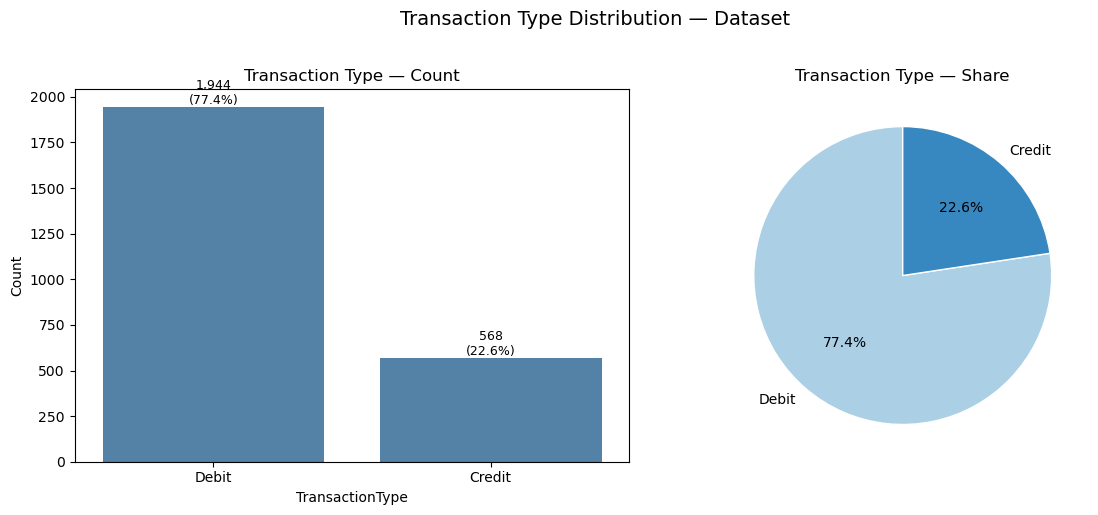

In [13]:
# Categorical distributions
def plot_transaction_type_distribution(df, dataset_name=None):
    col = "TransactionType"
    value_counts = df[col].value_counts()
    total = value_counts.sum()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[0], color="steelblue")
    for i, v in enumerate(value_counts.values):
        pct = v / total * 100
        axes[0].text(i, v, f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
    axes[0].set_title("Transaction Type — Count")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    # Pie chart
    axes[1].pie(
        value_counts.values,
        labels=value_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Blues", len(value_counts)),
        wedgeprops={"edgecolor": "white", "linewidth": 1}
    )
    axes[1].set_title("Transaction Type — Share")

    title = f"Transaction Type Distribution — {dataset_name}" if dataset_name else "Transaction Type Distribution"
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_transaction_type_distribution(df, dataset_name="Dataset")

**Insights on Categorical Feature Distributions**  
- **TransactionType:** Debit transactions dominate at 77.4% (1,944 of 2,512), while Credit accounts for the remaining 22.6% — a clear imbalance between the two transaction types.  

**Result:**  

Debit is the default, expected behavior in this dataset, making it the baseline for "normal" transaction activity. Because Credit transactions are the minority, a Credit transaction paired with other unusual signals (like a high login attempt count or an unusually large amount) may be more worth flagging than a Debit transaction showing the same traits — simply because it deviates further from what's typical.

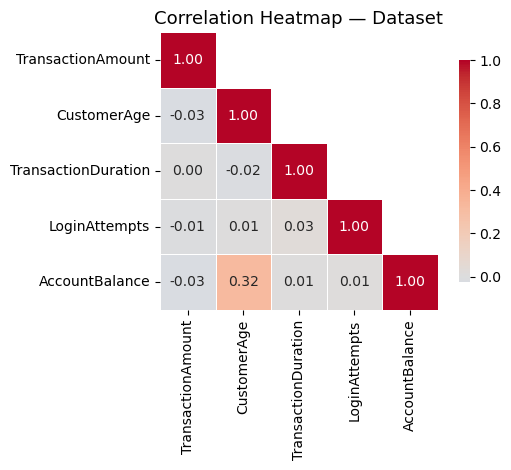

In [14]:
# Correlation heatmap
def plot_correlation_heatmap(df, numeric_cols=None, dataset_name=None):
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    # Drop columns with zero variance — they'd show as blank/NaN correlations
    numeric_cols = [c for c in numeric_cols if df[c].nunique() > 1]

    if len(numeric_cols) < 2:
        print("Not enough numerical columns with variation to compute correlations.")
        return

    corr = df[numeric_cols].corr()

    fig_size = max(6, len(numeric_cols) * 0.9)
    plt.figure(figsize=(fig_size, fig_size * 0.8))

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide redundant upper triangle
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

    title = f"Correlation Heatmap — {dataset_name}" if dataset_name else "Correlation Heatmap"
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_correlation_heatmap(df, dataset_name="Dataset")

**Insights on Correlation Heatmap**
- All pairwise correlations among the original numerical features (`TransactionAmount`, `CustomerAge`, `TransactionDuration`, `AccountBalance`, `LoginAttempts`) are weak, staying close to 0 in both directions.

- No pair of features shows a strong linear relationship, positive or negative.

**Result:**  

The lack of strong correlation is actually a good sign for modeling — it means the original features carry mostly independent information rather than repeating the same signal. This also means no feature needs to be dropped for redundancy, and any predictive signal found later will need to come from engineered features and combinations, not from a single strongly correlated column.


In [15]:
df = df.sort_values(["AccountID", "TransactionDate"])

# Time-based features
df["TxnHour"] = df["TransactionDate"].dt.hour
df["TxnDayOfWeek"] = df["TransactionDate"].dt.dayofweek
df["HoursSincePrevTxn"] = (df["TransactionDate"] - df["PreviousTransactionDate"]).dt.total_seconds() / 3600

# Behavioral features: deviation from the account's own average amount
acct_stats = df.groupby("AccountID")["TransactionAmount"].agg(["mean", "std"]).rename(
    columns={"mean": "AcctAvgAmount", "std": "AcctStdAmount"}
)
df = df.merge(acct_stats, on="AccountID", how="left")
df["AmountZScore"] = (df["TransactionAmount"] - df["AcctAvgAmount"]) / df["AcctStdAmount"].replace(0, np.nan)
df["AmountZScore"] = df["AmountZScore"].fillna(0)

# New device / new location flags (first time this account used this device or location)
df["FirstSeenDevice"] = ~df.duplicated(subset=["AccountID", "DeviceID"], keep="first")
df["FirstSeenLocation"] = ~df.duplicated(subset=["AccountID", "Location"], keep="first")

# Ratio feature
df["AmountToBalanceRatio"] = df["TransactionAmount"] / df["AccountBalance"].replace(0, np.nan)
df["AmountToBalanceRatio"] = df["AmountToBalanceRatio"].fillna(0)

**Insights on Engineered Features**
- **Time-based features** (`TxnHour`, `TxnDayOfWeek`, `HoursSincePrevTxn`) capture when a transaction happened and how long since the same account's last activity, useful for spotting oddly timed or oddly spaced-out transactions.

- **AmountZScore** measures how far a transaction sits from that specific account's own average amount, rather than comparing it against the whole dataset — this makes the feature personalized per account instead of using one fixed threshold for everyone.

- **FirstSeenDevice / FirstSeenLocation** flag the first time an account uses a given device or location, a common real-world signal used by banks to catch account takeover attempts.

- **AmountToBalanceRatio** compares the transaction size to the account's current balance, capturing cases where a transaction uses up most or all of the available funds.

**Result:**  

None of these behavioral features existed in the raw dataset — they were all derived from combining `TransactionAmount`, `AccountID`, `DeviceID`, `Location`, and the date columns. This is what allows the anomaly detection models later on to judge a transaction relative to that account's own history, rather than just its raw values.


In [16]:
# Handle skew (log-transform heavily skewed amount features)
from scipy.stats import skew

for col in ["TransactionAmount", "AmountToBalanceRatio"]:
    print(col, "skew:", skew(df[col]))

df["LogTransactionAmount"] = np.log1p(df["TransactionAmount"])

TransactionAmount skew: 1.739067472794457
AmountToBalanceRatio skew: 6.7503298851851765


**Result:**  

`TransactionAmount` (skew +1.74) and `AmountToBalanceRatio` (skew +6.75) are both heavily right-skewed, confirming the same pattern already seen in the earlier EDA skewness check. A log transform is applied to `TransactionAmount`, producing `LogTransactionAmount`, which compresses the large values and gives the model a more balanced version of this feature to work with.


In [17]:
feature_cols = [
    "LogTransactionAmount", "AmountZScore", "AmountToBalanceRatio",
    "TransactionDuration", "LoginAttempts", "TxnHour", "HoursSincePrevTxn",
    "FirstSeenDevice", "FirstSeenLocation"
]

X = df[feature_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

**Result:**  

9 engineered features are selected (`LogTransactionAmount`, `AmountZScore`, `AmountToBalanceRatio`, `TransactionDuration`, `LoginAttempts`, `TxnHour`, `HoursSincePrevTxn`, `FirstSeenDevice`, `FirstSeenLocation`) and scaled using `StandardScaler`, so every feature contributes fairly to the model regardless of its original range. Identifier columns (like `TransactionID` and `AccountID`) and raw text columns are intentionally excluded, since they carry no numeric meaning on their own.


## Anomaly Detection

**Isolation Forest**  

Isolation Forest works by randomly splitting the data over and over. Transactions that are unusual are easier to isolate from the rest, needing fewer splits, so they receive a higher anomaly score. `contamination=0.03` tells the model to assume about 3% of transactions are anomalies — this is an assumption, not something the model measured on its own.


In [18]:
# Isolation Forest — primary model
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
df["IsoAnomaly"] = iso.fit_predict(X_scaled)          # -1 = anomaly, 1 = normal
df["IsoScore"] = -iso.decision_function(X_scaled)       # higher = more anomalous

print(df["IsoAnomaly"].value_counts())

IsoAnomaly
 1    2436
-1      76
Name: count, dtype: int64


**Result:**  

The model flagged **76 out of 2,512 transactions (about 3%)** as anomalies, matching the `contamination=0.03` setting, which is expected since that percentage was explicitly given to the model rather than discovered by it.


**DBSCAN**  

DBSCAN takes a different approach — it groups transactions into clusters based on how closely packed together they are, and marks anything that doesn't belong to a dense cluster as "noise" (label -1), which is treated as a second, independent anomaly signal.


In [19]:
# DBSCAN — secondary method (density-based, catches different anomaly shapes)
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["DBSCANCluster"] = dbscan.fit_predict(X_scaled)      # -1 = noise/outlier

print(df["DBSCANCluster"].value_counts())

DBSCANCluster
 0    2206
-1     157
 1     116
 2      16
 3       7
 4       5
 5       5
Name: count, dtype: int64


**Result:**  

DBSCAN flagged **157 transactions** as noise, compared to 76 from Isolation Forest, and found 6 separate normal clusters of varying sizes. This difference is expected, since the two models define "unusual" differently — Isolation Forest looks at how easy a point is to isolate, while DBSCAN looks at how dense an area of the data is. Using both together gives a more well-rounded view than relying on either one alone.


**Visualizing the Anomalies with PCA**  

Since the data has 9 features, it can't be plotted directly. PCA compresses it down into 2 combined dimensions (PC1 and PC2) so the anomalies flagged by Isolation Forest can be viewed visually.


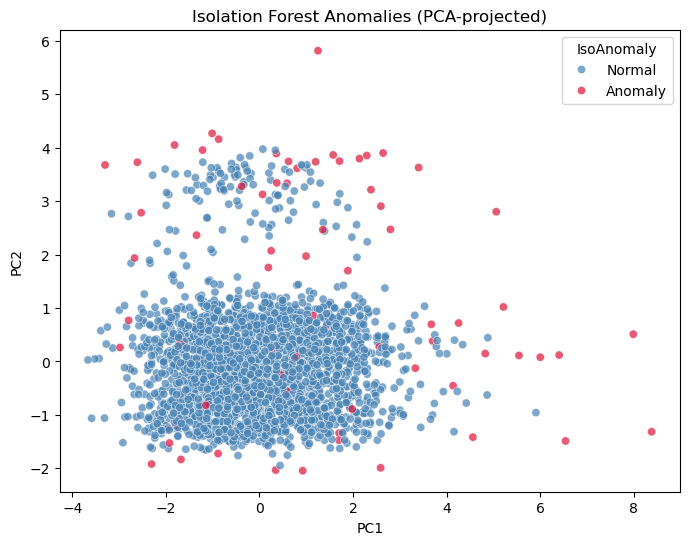

In [20]:
# Visualize in 2D via PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = components[:, 0], components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue=df["IsoAnomaly"].map({1: "Normal", -1: "Anomaly"}),
                 palette={"Normal": "steelblue", "Anomaly": "crimson"}, alpha=0.7)
plt.title("Isolation Forest Anomalies (PCA-projected)")
plt.show()

**Result:**  

The flagged anomalies (red) mostly sit toward the outer edges of the point cloud, while normal transactions (blue) form a denser cluster near the center. This separation is a good sign — it shows the model is picking up on a real pattern in the data rather than flagging random points, even though some overlap between colors is expected since this view only shows 2 of the original 9 dimensions.


## Synthetic Fraud Validation

Since this dataset has no real fraud labels, there's no direct way to check if the model is truly catching fraud. To test it, fake (synthetic) fraud-like transactions are created by taking 50 existing transactions and making them look suspicious — increasing the amount by 4 to 8 times, raising login attempts, and marking the device/location as new. The engineered features are recalculated for these rows so the model actually sees the injected suspicious values, then combined with the original data into `df_test`.


In [21]:
def inject_synthetic_fraud(df, n=50, seed=42):
    rng = np.random.default_rng(seed)
    fraud_rows = df.sample(n, random_state=seed).copy()

    fraud_rows["TransactionAmount"] *= rng.uniform(4, 8, size=n)
    fraud_rows["LoginAttempts"] = rng.integers(5, 10, size=n)
    fraud_rows["FirstSeenDevice"] = True
    fraud_rows["FirstSeenLocation"] = True
    fraud_rows["IsSyntheticFraud"] = 1

    fraud_rows["LogTransactionAmount"] = np.log1p(fraud_rows["TransactionAmount"])
    fraud_rows["AmountZScore"] = (fraud_rows["TransactionAmount"] - fraud_rows["AcctAvgAmount"]) / fraud_rows["AcctStdAmount"].replace(0, np.nan)
    fraud_rows["AmountZScore"] = fraud_rows["AmountZScore"].fillna(0)
    fraud_rows["AmountToBalanceRatio"] = fraud_rows["TransactionAmount"] / fraud_rows["AccountBalance"].replace(0, np.nan)
    fraud_rows["AmountToBalanceRatio"] = fraud_rows["AmountToBalanceRatio"].fillna(0)

    df["IsSyntheticFraud"] = 0
    combined = pd.concat([df, fraud_rows], ignore_index=True)
    return combined

df_test = inject_synthetic_fraud(df, n=50)

**Result:**  

50 synthetic fraud transactions are added to the original 2,512, bringing `df_test` to 2,562 rows total, with an `IsSyntheticFraud` column marking which ones are the injected fake fraud cases.


**Evaluating the Model**  

Isolation Forest is re-run on the combined dataset, then checked against the known synthetic fraud labels using precision, recall, and ROC-AUC to see how well it separates the fake fraud from normal transactions.


In [22]:
# Evaluate: does the model flag the injected fraud more than normal transactions?
X_test = df_test[feature_cols].fillna(0)
X_test_scaled = StandardScaler().fit_transform(X_test)

iso_test = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
df_test["IsoAnomaly"] = iso_test.fit_predict(X_test_scaled)
df_test["IsoScore"] = -iso_test.decision_function(X_test_scaled)

y_true = df_test["IsSyntheticFraud"]
y_pred = (df_test["IsoAnomaly"] == -1).astype(int)

print(classification_report(y_true, y_pred, target_names=["Normal", "Synthetic Fraud"]))
print("ROC-AUC (using anomaly score):", roc_auc_score(y_true, df_test["IsoScore"]))

                 precision    recall  f1-score   support

         Normal       0.99      0.98      0.99      2512
Synthetic Fraud       0.44      0.68      0.54        50

       accuracy                           0.98      2562
      macro avg       0.72      0.83      0.76      2562
   weighted avg       0.98      0.98      0.98      2562

ROC-AUC (using anomaly score): 0.9839490445859872


**Result:**  

| Metric | Normal | Synthetic Fraud |
|---|---|---|
| Precision | 0.99 | 0.44 |
| Recall | 0.98 | 0.68 |
| F1-score | 0.99 | 0.54 |

**ROC-AUC: 0.98**

- An ROC-AUC of 0.98 is strong, showing the model ranks fraud-like transactions as far more suspicious than normal ones almost all the time.

- A recall of 0.68 means the model caught about 68% of the injected fraud, while 32% slipped through undetected.

- A precision of 0.44 means less than half of what got flagged was the injected fraud — the rest were other unusual transactions, which is expected since Isolation Forest flags any unusual behavior, not fraud specifically.

- Lowering the anomaly threshold would likely catch more fraud (higher recall) at the cost of more false alarms (lower precision) — a real bank would need to weigh which mistake is more costly.


## Understand the Flagged Transactions

With anomalies flagged, it helps to see what actually separates them from normal transactions, rather than treating the model as a black box. Average feature values are compared between the flagged (anomaly) group and the normal group.


In [23]:
# Profile what the flagged (real) anomalies have in common
anomalies = df[df["IsoAnomaly"] == -1]
normal = df[df["IsoAnomaly"] == 1]

comparison = pd.DataFrame({
    "Anomaly_mean": anomalies[feature_cols].mean(),
    "Normal_mean": normal[feature_cols].mean()
})
comparison

,Anomaly_mean,Normal_mean
LogTransactionAmount,5.508938,5.133061
AmountZScore,0.571863,-0.017841
AmountToBalanceRatio,1.043660,0.173693
TransactionDuration,138.407895,119.057882
LoginAttempts,2.684211,1.075944
TxnHour,17.157895,16.609606
HoursSincePrevTxn,-11142.268439,-11717.008463
FirstSeenDevice,0.973684,0.995895
FirstSeenLocation,0.578947,0.954023


**Result:** Transactions flagged as anomalies show clear differences from normal ones:
- **Higher amount z-score** (0.57 vs -0.02) — the transaction amount sits further from what that account usually spends.

- **More login attempts** (2.68 vs 1.08 on average) — flagged transactions involved noticeably more login attempts.

- **Longer transaction duration** (138.4 vs 119.1 seconds) — flagged transactions took a bit longer to complete.

- **Much higher amount-to-balance ratio** (1.04 vs 0.17) — the transaction amount sits close to, or even above, the account's balance.

- **Lower first-seen-location rate** (0.58 vs 0.95) — most anomalies are actually *not* from a new location, suggesting amount and login behavior drive the flagging more than location changes.

These patterns line up with what a fraud analyst would consider worth reviewing — an unusually large transaction paired with extra login attempts is a reasonable combination to flag, even without confirming it as fraud.


**Top Riskiest Transactions**  

Instead of a plain yes/no anomaly label, every transaction can be ranked by its anomaly score. This lets a fraud team prioritize the highest-risk cases first, instead of treating every flagged transaction with equal urgency.


In [24]:
# Top 1% riskiest transactions (rank by score rather than hard cutoff — more realistic for a bank)
top_risk = df.sort_values("IsoScore", ascending=False).head(int(len(df) * 0.01))
top_risk[["TransactionID", "AccountID", "TransactionAmount", "Channel", "IsoScore"]]

,TransactionID,AccountID,TransactionAmount,Channel,IsoScore
2290,TX000275,AC00454,1176.28,ATM,0.111843
1634,TX000395,AC00326,6.30,Branch,0.101690
429,TX000899,AC00083,1531.31,Online,0.080553
2147,TX000230,AC00427,630.24,ATM,0.074692
912,TX000166,AC00182,231.91,ATM,0.073988
1588,TX001056,AC00317,13.48,Online,0.071524
111,TX001259,AC00020,603.23,Branch,0.071398
1676,TX001732,AC00333,1.93,Branch,0.067212
2422,TX001973,AC00480,1087.90,ATM,0.067155
1310,TX000455,AC00264,611.11,ATM,0.063240


**Result:**  

This table lists the **top 1% of transactions** with the highest anomaly scores across the dataset. In a real fraud review process, these would be the very first transactions an analyst should check, since they represent the most unusual behavior the model detected.


<div style="text-align: left;">
    <font size="5" color="white"><b>Conclusion and Limitations</b></font>
</div>

**Summary**
- A bank transaction dataset containing 2,512 transactions across 16 original columns was loaded, explored, and checked for quality, finding no missing values or duplicates, alongside 235 outlier values across 2 numeric features.

- New behavior-based features were engineered, including transaction timing, amount deviation from account average, new device/location flags, and amount-to-balance ratio.

- Two unsupervised anomaly detection models, Isolation Forest and DBSCAN, were applied and compared, flagging 76 and 157 transactions respectively.

- The approach was validated using 50 simulated fraud transactions, achieving a strong ROC-AUC of 0.98 and a recall of 0.68.

- The features most distinguishing flagged transactions from normal ones were reviewed, and the top 1% riskiest transactions were ranked for review.

**Limitations**
- **No real fraud labels** — the dataset has no confirmed fraud column, so real-world accuracy cannot be fully proven. Validation relied on simulated fraud, not actual confirmed fraud cases.

- **Assumed contamination rate** — the `contamination=0.03` setting is an assumption, not a number the model discovered on its own.

- **Small dataset size** — with only 2,512 rows, results may not generalize to a much larger, real-world banking system.

- **Model disagreement** — Isolation Forest and DBSCAN did not fully agree (76 vs 157 flagged transactions), showing "anomaly" is not one single, fixed definition.

- **Simulated fraud is simplified** — the fake fraud transactions used a few obvious changes (higher amount, more login attempts, new device). Real fraud may be more subtle than what was simulated here.

**Possible Next Steps**
- Test on a dataset with real, confirmed fraud labels to properly measure real-world precision and recall.

- Try additional anomaly detection models (such as Local Outlier Factor or an autoencoder) for further comparison.

- Test on a larger dataset covering a longer time period, to see if the same patterns hold up at scale.

- Build a simple dashboard or report to present flagged transactions in a way a non-technical fraud analyst could use directly.
